# Implementasi Kecerdasan Buatan untuk Optimalisasi Layanan Hybrid Library
## Pendekatan Content-Based Filtering pada Sistem Rekomendasi Buku

Studi kasus: Perpustakaan Kampus — Fakultas Sains, Teknologi, & Kesehatan dan
Fakultas Sosial, Humaniora, & Seni

**Alur notebook:**
1. Import & Eksplorasi Data (EDA)
2. Preprocessing Teks (Sastrawi)
3. Feature Extraction (TF-IDF)
4. Content-Based Filtering (Cosine Similarity)
5. Evaluasi Model
6. Contoh Rekomendasi


## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Eksplorasi Data Analisis

In [2]:
df_book = pd.read_csv('data/buku.csv')
df_user = pd.read_csv('data/pengguna.csv')
df_trs = pd.read_csv('data/transaksi.csv')

print("Jumlah Buku (Fisik/E-book)     : ", len(df_book))
print("Jumlah User (Mhs/Dosen)        : ", len(df_user))
print("Jumlah transaksi peminjaman    : ", len(df_trs))

Jumlah Buku (Fisik/E-book)     :  1379
Jumlah User (Mhs/Dosen)        :  380
Jumlah transaksi peminjaman    :  3500


In [3]:
# Analisis variabel dependen dan independen dari data buku
df_book.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1379 entries, 0 to 1378
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id_buku           1379 non-null   object
 1   judul             1379 non-null   object
 2   pengarang         1379 non-null   object
 3   penerbit          1379 non-null   object
 4   tahun_terbit      1379 non-null   int64 
 5   fakultas_terkait  1379 non-null   object
 6   prodi_terkait     1379 non-null   object
 7   kategori          1379 non-null   object
 8   sinopsis          1379 non-null   object
 9   tags              1379 non-null   object
 10  bahasa            1379 non-null   object
 11  jenis_koleksi     1379 non-null   object
 12  jumlah_halaman    1379 non-null   int64 
 13  isbn              1379 non-null   object
 14  stok              1379 non-null   int64 
dtypes: int64(3), object(12)
memory usage: 161.7+ KB


In [4]:
df_book.head()

,id_buku,judul,pengarang,penerbit,tahun_terbit,fakultas_terkait,prodi_terkait,kategori,sinopsis,tags,bahasa,jenis_koleksi,jumlah_halaman,isbn,stok
0,BK00001,Dasar Pemrograman Berorientasi Objek Edisi Ke-2,"Balidin Dongoran, S.T.",Gramedia Pustaka Utama,2024,"Fakultas Sains, Teknologi, & Kesehatan",Informatika,Pemrograman & Algoritma,Buku ini menyajikan kajian komprehensif mengen...,"struktur data, pemrograman, java, algoritma",Indonesia,E-book,452,978-0-218-19600-9,9999
1,BK00002,Pengantar Web Development,Darimin Pradipta,Andi Publisher,2008,"Fakultas Sains, Teknologi, & Kesehatan",Informatika,Pemrograman & Algoritma,Buku ini menyajikan kajian komprehensif mengen...,"algoritma, coding, struktur data, java",Inggris,Fisik,303,978-0-86379-402-5,5
2,BK00003,Dasar Web Development,"Lintang Siregar, S.T.",Erlangga,2007,"Fakultas Sains, Teknologi, & Kesehatan",Informatika,Pemrograman & Algoritma,Buku ini dirancang sebagai panduan untuk memah...,"coding, algoritma, pemrograman, python",Indonesia,Fisik,160,978-0-511-61559-7,3
3,BK00004,Pemrograman Pemrograman Berorientasi Objek unt...,Yani Gunawan,Kencana Prenada,2022,"Fakultas Sains, Teknologi, & Kesehatan",Informatika,Pemrograman & Algoritma,Buku ini dirancang sebagai panduan untuk memah...,"python, kompleksitas, coding, struktur data",Indonesia,Fisik,314,978-0-618-49593-1,4
4,BK00005,C++: Konsep dan Implementasi,"Betania Gunawan, S.H.",Elex Media Komputindo,2015,"Fakultas Sains, Teknologi, & Kesehatan",Informatika,Pemrograman & Algoritma,Buku ini menyajikan kajian komprehensif mengen...,"java, coding, algoritma, python",Inggris,Fisik,449,978-0-316-47525-9,7


In [5]:
# Analisis Jumlah Buku Per Kategori
df_book['kategori'].value_counts()

kategori
Jaringan & Keamanan Siber                    93
Basis Data                                   86
Teknologi Farmasi & Pelayanan Kefarmasian    86
Fotografi & Multimedia                       86
Keperawatan Klinis                           84
Desain Interior & Arsitektur Ruang           83
Ergonomi & Rantai Pasok                      81
Teknik Industri & Manajemen Operasi          79
Kewirausahaan & Pemasaran Bisnis             78
Jurnalistik & Media Digital                  76
Desain Komunikasi Visual & Ilustrasi         73
Farmakologi & Kefarmasian                    72
Keperawatan Profesi Ners                     69
Kecerdasan Buatan & Data Science             69
Komunikasi & Media                           68
Pemrograman & Algoritma                      67
Psikologi Umum & Klinis                      66
Administrasi & Manajemen Bisnis              63
Name: count, dtype: int64

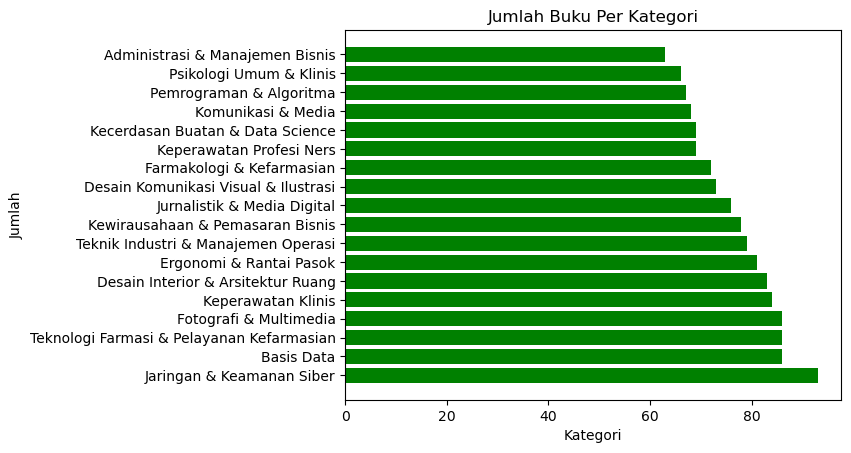

In [6]:
# Visualisasi
category = df_book['kategori'].value_counts()
plt.barh(category.index, category.values, color='green')
plt.title('Jumlah Buku Per Kategori')
plt.xlabel('Kategori')
plt.ylabel('Jumlah')
plt.show()

In [7]:
# Analisis Jumlah Buku per Fakultas
df_book['fakultas_terkait'].value_counts()

fakultas_terkait
Fakultas Sains, Teknologi, & Kesehatan    786
Fakultas Sosial, Humaniora, & Seni        593
Name: count, dtype: int64

In [8]:
# Analisis Jumlah Buku per Prodi
prodi = df_book['prodi_terkait'].value_counts()
prodi

prodi_terkait
Informatika                 315
Teknik Industri             160
Desain Komunikasi Visual    159
Farmasi                     158
Ilmu Komunikasi             144
Administrasi Bisnis         141
Keperawatan                  84
Desain Interior              83
Profesi Ners                 69
Psikologi                    66
Name: count, dtype: int64

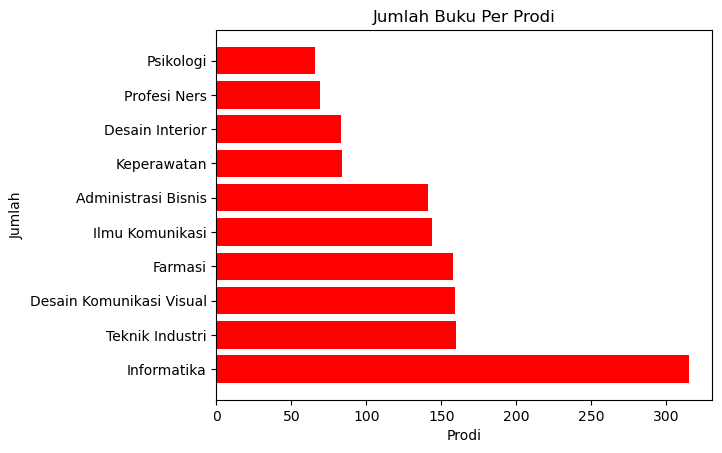

In [9]:
# Visualisasi
plt.barh(prodi.index, prodi.values, color='red')
plt.title('Jumlah Buku Per Prodi')
plt.xlabel('Prodi')
plt.ylabel('Jumlah')
plt.show()

In [10]:
# Filter data yang BUKAN 'E-book' dan jumlahkan berdasarkan fakultas
stok_non_ebook = df_book[df_book['jenis_koleksi'] != 'E-book'].groupby('fakultas_terkait')['stok'].sum()

print(stok_non_ebook)

fakultas_terkait
Fakultas Sains, Teknologi, & Kesehatan    2154
Fakultas Sosial, Humaniora, & Seni        1526
Name: stok, dtype: int64


In [11]:
# Analisis Tahun Terbit
thn_t = df_book['tahun_terbit'].value_counts()
thn_t_sort = thn_t.sort_index(ascending=False)
thn_t_sort

tahun_terbit
2024    72
2023    67
2022    87
2021    75
2020    66
2019    53
2018    77
2017    57
2016    56
2015    57
2014    83
2013    57
2012    70
2011    65
2010    60
2009    86
2008    76
2007    80
2006    64
2005    71
Name: count, dtype: int64

In [12]:
thn_t_sum_new = thn_t[thn_t.index >= 2020].sum()
thn_t_sum_old = thn_t[thn_t.index < 2020].sum()

print(f'Buku terbitan baru (2020+): {thn_t_sum_new}')
print(f'Buku terbitan lama (-2020): {thn_t_sum_old}')

Buku terbitan baru (2020+): 367
Buku terbitan lama (-2020): 1012


**HASIL ANALISIS :** <br>

Buku didominasi dari Fakultas Sains, Teknologi, dan Kesehatan dengan Prodi Informatika paling dominan. Sementara untuk Fakultas Sosial, Humaniora dan Seni memiliki banyak buku untuk prodi Desain Komunikasi Visual. <br>

Untuk persediaan buku fisik, FSTK memiliki total `2154 buku fisik` sementara FSHS memiliki total `1526 buku fisik` <br>

Untuk Tahun Terbitan Buku, buku terbitan lama 3x lebih banyak dari buku terbitan baru

In [13]:
# Analisis pada data User
df_user.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id_user     380 non-null    object 
 1   nama        380 non-null    object 
 2   jenis_user  380 non-null    object 
 3   fakultas    380 non-null    object 
 4   prodi       380 non-null    object 
 5   angkatan    350 non-null    float64
dtypes: float64(1), object(5)
memory usage: 17.9+ KB


In [14]:
df_user.head()

,id_user,nama,jenis_user,fakultas,prodi,angkatan
0,USR00001,Mahesa Usada,Mahasiswa,"Fakultas Sains, Teknologi, & Kesehatan",Farmasi,2025.0
1,USR00002,Puti Najmudin,Mahasiswa,"Fakultas Sosial, Humaniora, & Seni",Ilmu Komunikasi,2024.0
2,USR00003,"Baktianto Suryono, S.Pd",Mahasiswa,"Fakultas Sains, Teknologi, & Kesehatan",Profesi Ners,2023.0
3,USR00004,Zizi Nurdiyanti,Mahasiswa,"Fakultas Sosial, Humaniora, & Seni",Administrasi Bisnis,2022.0
4,USR00005,Drs. Harjo Winarno,Mahasiswa,"Fakultas Sosial, Humaniora, & Seni",Psikologi,2021.0


In [15]:
# Analisis perbandingan User Mahasiswa dan Dosen
df_user['jenis_user'].value_counts()

jenis_user
Mahasiswa    350
Dosen         30
Name: count, dtype: int64

In [16]:
faculty = df_user['fakultas'].value_counts()
faculty

fakultas
Fakultas Sains, Teknologi, & Kesehatan    201
Fakultas Sosial, Humaniora, & Seni        179
Name: count, dtype: int64

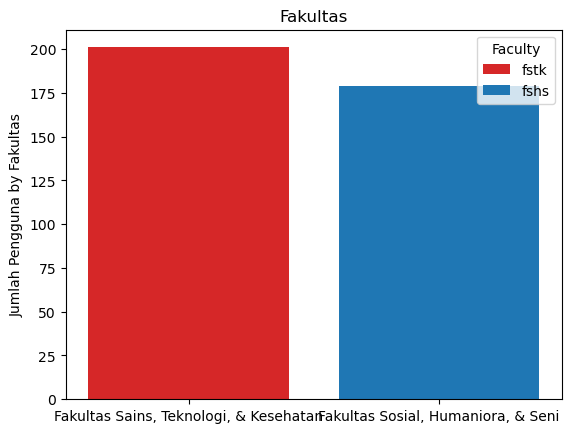

In [17]:
# Analisis Perbandingan Fakultas
faculty = df_user['fakultas'].value_counts()

fig, ax = plt.subplots()

index = faculty.index
values = faculty.values
bar_labels = ['fstk', 'fshs']
bar_colors = ['tab:red', 'tab:blue']

ax.bar(index, values, label=bar_labels, color=bar_colors)

ax.set_ylabel('Jumlah Pengguna by Fakultas')
ax.set_title('Fakultas')
ax.legend(title='Faculty')

plt.show()

In [18]:
# Analisis Berdasarkan Angkatan
angkatan = df_user['angkatan'].value_counts()
angkatan.sort_values(ascending=False)

angkatan
2023.0    66
2025.0    59
2022.0    59
2021.0    58
2020.0    55
2024.0    53
Name: count, dtype: int64

In [19]:
# Analisis Berdasarkan Prodi
prodi = df_user['prodi'].value_counts()
prodi.sort_values(ascending=False)

prodi
Keperawatan                 45
Psikologi                   45
Teknik Industri             44
Ilmu Komunikasi             44
Informatika                 42
Farmasi                     36
Desain Interior             35
Profesi Ners                34
Desain Komunikasi Visual    32
Administrasi Bisnis         23
Name: count, dtype: int64

**Hasil Analisis Data Pengguna:** <br>
Pengguna terdaftar terdiri dari `350 mahasiswa/i dan 30 dosen` <br>
Jumlah Perbandingan pengguna antar fakultas : `FSTK lebih tinggi dibanding FSHS (201:179)` <br>
Pengguna tertinggi dari angkatan : `2023` <br>
Program Studi Pengguna tertinggi : `Keperawatan dan Psikologi`

In [20]:
# Analisis Data Transaksi Peminjaman Buku
df_trs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id_transaksi             3500 non-null   object 
 1   id_user                  3500 non-null   object 
 2   id_buku                  3500 non-null   object 
 3   tanggal_pinjam           3500 non-null   object 
 4   tanggal_kembali_rencana  3500 non-null   object 
 5   tanggal_kembali_aktual   3445 non-null   object 
 6   status                   3500 non-null   object 
 7   rating                   2005 non-null   float64
dtypes: float64(1), object(7)
memory usage: 218.9+ KB


In [21]:
df_trs.head()

,id_transaksi,id_user,id_buku,tanggal_pinjam,tanggal_kembali_rencana,tanggal_kembali_aktual,status,rating
0,TRX000001,USR00267,BK00570,1/30/2024,2/13/2024,2/16/2024,Terlambat,4.0
1,TRX000002,USR00299,BK00721,10/27/2024,11/10/2024,11/1/2024,Dikembalikan,NaN
2,TRX000003,USR00102,BK00855,2/28/2025,3/14/2025,3/5/2025,Dikembalikan,NaN
3,TRX000004,USR00053,BK01005,5/25/2023,6/8/2023,5/28/2023,Dikembalikan,NaN
4,TRX000005,USR00132,BK00478,7/1/2024,7/15/2024,7/9/2024,Dikembalikan,NaN


In [22]:
# Drop Rating
df_trs = df_trs.drop(columns=['rating'])

In [23]:
df_trs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   id_transaksi             3500 non-null   object
 1   id_user                  3500 non-null   object
 2   id_buku                  3500 non-null   object
 3   tanggal_pinjam           3500 non-null   object
 4   tanggal_kembali_rencana  3500 non-null   object
 5   tanggal_kembali_aktual   3445 non-null   object
 6   status                   3500 non-null   object
dtypes: object(7)
memory usage: 191.5+ KB


In [24]:
# Analisis Status
status = df_trs['status'].value_counts()
status

status
Dikembalikan    2130
Terlambat       1315
Dipinjam          55
Name: count, dtype: int64

In [25]:
id_buku_terpinjam = df_trs['id_buku'].value_counts()
id_buku_terpinjam_sorted = id_buku_terpinjam.sort_values(ascending=False)
print("Buku terpinjam dari yang paling banyak: ", id_buku_terpinjam_sorted)

# Buku terpinjam terbanyak
most_terpinjam = id_buku_terpinjam[id_buku_terpinjam.values >= 9]
print('Buku paling banyak terpinjam: ', most_terpinjam)

Buku terpinjam dari yang paling banyak:  id_buku
BK01190    11
BK01224    10
BK01222    10
BK01207    10
BK01221    10
           ..
BK00143     1
BK00374     1
BK00411     1
BK00236     1
BK00056     1
Name: count, Length: 1230, dtype: int64
Buku paling banyak terpinjam:  id_buku
BK01190    11
BK01224    10
BK01207    10
BK01222    10
BK01221    10
BK00757     9
BK00521     9
BK01172     9
Name: count, dtype: int64


In [26]:
list_buku_paling_sering_dipinjam = ['BK01190', 'BK01224', 'BK01207', 'BK01222', 'BK01221', 'BK00757', 'BK00521', 'BK01172']

nama_buku_paling_banyak_dipinjam = df_book[df_book['id_buku'].isin(list_buku_paling_sering_dipinjam)]
nama_buku_paling_banyak_dipinjam

,id_buku,judul,pengarang,penerbit,tahun_terbit,fakultas_terkait,prodi_terkait,kategori,sinopsis,tags,bahasa,jenis_koleksi,jumlah_halaman,isbn,stok
520,BK00521,Dasar-Dasar Keperawatan Gawat Darurat,Irnanto Rajata,Alfabeta,2010,"Fakultas Sains, Teknologi, & Kesehatan",Keperawatan,Keperawatan Klinis,Buku ini dirancang sebagai panduan untuk memah...,"praktik klinis, keperawatan, keperawatan anak,...",Indonesia,Fisik,143,978-0-380-55257-3,0
756,BK00757,Modul Profesi Ners,Mustika Siregar,Kencana Prenada,2019,"Fakultas Sains, Teknologi, & Kesehatan",Profesi Ners,Keperawatan Profesi Ners,Buku ini memberikan pemahaman menyeluruh tenta...,"kompetensi ners, praktik klinis ners, residens...",Indonesia,Fisik,281,978-0-674-47163-4,8
1171,BK01172,Psikologi Umum: Teori dan Aplikasi Edisi Ke-3,Dodo Pudjiastuti,PT Grasindo,2014,"Fakultas Sosial, Humaniora, & Seni",Psikologi,Psikologi Umum & Klinis,Buku ini menyajikan kajian komprehensif mengen...,"kepribadian, kesehatan mental, psikologi, perk...",Indonesia,Fisik,455,978-0-571-55868-1,2
1189,BK01190,Dasar-Dasar Psikologi Umum Edisi Revisi,"Lutfan Namaga, S.Pt",PT Grasindo,2007,"Fakultas Sosial, Humaniora, & Seni",Psikologi,Psikologi Umum & Klinis,Buku ini membahas secara mendalam tentang gang...,"psikoterapi, psikologi, kepribadian, kesehatan...",Inggris,E-book,306,978-0-8217-8192-0,9999
1206,BK01207,Pengantar Psikologi Abnormal,Daru Januar,Rajawali Pers,2023,"Fakultas Sosial, Humaniora, & Seni",Psikologi,Psikologi Umum & Klinis,Buku ini membahas secara mendalam tentang dina...,"psikologi klinis, psikologi sosial, perkembang...",Inggris,Fisik,298,978-1-77269-608-0,0
1220,BK01221,Memahami Psikologi Perkembangan Edisi Ke-3,Galih Laksita,PT Grasindo,2009,"Fakultas Sosial, Humaniora, & Seni",Psikologi,Psikologi Umum & Klinis,Buku ini memberikan pemahaman menyeluruh tenta...,"psikologi sosial, kesehatan mental, psikoterap...",Indonesia,Fisik,498,978-0-362-79246-1,8
1221,BK01222,Memahami Psikologi Kepribadian Edisi Ke-2,Caket Budiyanto,Deepublish,2010,"Fakultas Sosial, Humaniora, & Seni",Psikologi,Psikologi Umum & Klinis,Buku ini dirancang sebagai panduan untuk memah...,"psikologi klinis, kepribadian, kesehatan menta...",Indonesia,Fisik,506,978-1-4767-7537-1,1
1223,BK01224,Psikologi Umum: Teori dan Aplikasi,Liman Sihombing,Informatika Bandung,2009,"Fakultas Sosial, Humaniora, & Seni",Psikologi,Psikologi Umum & Klinis,Buku ini memberikan pemahaman menyeluruh tenta...,"psikoterapi, psikologi, kepribadian, perkemban...",Inggris,Fisik,254,978-1-07-155348-0,5


In [27]:
# Join untuk buat data baru
join_buku_paling_terpinjam = pd.merge(
    most_terpinjam,
    nama_buku_paling_banyak_dipinjam,
    on='id_buku',
    how='inner'
)

join_buku_paling_terpinjam

,id_buku,count,judul,pengarang,penerbit,tahun_terbit,fakultas_terkait,prodi_terkait,kategori,sinopsis,tags,bahasa,jenis_koleksi,jumlah_halaman,isbn,stok
0,BK01190,11,Dasar-Dasar Psikologi Umum Edisi Revisi,"Lutfan Namaga, S.Pt",PT Grasindo,2007,"Fakultas Sosial, Humaniora, & Seni",Psikologi,Psikologi Umum & Klinis,Buku ini membahas secara mendalam tentang gang...,"psikoterapi, psikologi, kepribadian, kesehatan...",Inggris,E-book,306,978-0-8217-8192-0,9999
1,BK01224,10,Psikologi Umum: Teori dan Aplikasi,Liman Sihombing,Informatika Bandung,2009,"Fakultas Sosial, Humaniora, & Seni",Psikologi,Psikologi Umum & Klinis,Buku ini memberikan pemahaman menyeluruh tenta...,"psikoterapi, psikologi, kepribadian, perkemban...",Inggris,Fisik,254,978-1-07-155348-0,5
2,BK01207,10,Pengantar Psikologi Abnormal,Daru Januar,Rajawali Pers,2023,"Fakultas Sosial, Humaniora, & Seni",Psikologi,Psikologi Umum & Klinis,Buku ini membahas secara mendalam tentang dina...,"psikologi klinis, psikologi sosial, perkembang...",Inggris,Fisik,298,978-1-77269-608-0,0
3,BK01222,10,Memahami Psikologi Kepribadian Edisi Ke-2,Caket Budiyanto,Deepublish,2010,"Fakultas Sosial, Humaniora, & Seni",Psikologi,Psikologi Umum & Klinis,Buku ini dirancang sebagai panduan untuk memah...,"psikologi klinis, kepribadian, kesehatan menta...",Indonesia,Fisik,506,978-1-4767-7537-1,1
4,BK01221,10,Memahami Psikologi Perkembangan Edisi Ke-3,Galih Laksita,PT Grasindo,2009,"Fakultas Sosial, Humaniora, & Seni",Psikologi,Psikologi Umum & Klinis,Buku ini memberikan pemahaman menyeluruh tenta...,"psikologi sosial, kesehatan mental, psikoterap...",Indonesia,Fisik,498,978-0-362-79246-1,8
5,BK00757,9,Modul Profesi Ners,Mustika Siregar,Kencana Prenada,2019,"Fakultas Sains, Teknologi, & Kesehatan",Profesi Ners,Keperawatan Profesi Ners,Buku ini memberikan pemahaman menyeluruh tenta...,"kompetensi ners, praktik klinis ners, residens...",Indonesia,Fisik,281,978-0-674-47163-4,8
6,BK00521,9,Dasar-Dasar Keperawatan Gawat Darurat,Irnanto Rajata,Alfabeta,2010,"Fakultas Sains, Teknologi, & Kesehatan",Keperawatan,Keperawatan Klinis,Buku ini dirancang sebagai panduan untuk memah...,"praktik klinis, keperawatan, keperawatan anak,...",Indonesia,Fisik,143,978-0-380-55257-3,0
7,BK01172,9,Psikologi Umum: Teori dan Aplikasi Edisi Ke-3,Dodo Pudjiastuti,PT Grasindo,2014,"Fakultas Sosial, Humaniora, & Seni",Psikologi,Psikologi Umum & Klinis,Buku ini menyajikan kajian komprehensif mengen...,"kepribadian, kesehatan mental, psikologi, perk...",Indonesia,Fisik,455,978-0-571-55868-1,2


In [28]:
join_buku_paling_terpinjam.to_csv('data/daftar-buku-paling-banyak-dipinjam.csv')

In [29]:
# Analisis Identitas Peminjam (Prodi)
# Base ID_User (join Transaksi dan User)
identitas_peminjam = pd.merge(
    df_user,
    df_trs,
    on='id_user',
    how='inner'
)

identitas_peminjam.info()
# save to csv
identitas_peminjam.to_csv('data/daftar-identitas-peminjam.csv')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id_user                  3500 non-null   object 
 1   nama                     3500 non-null   object 
 2   jenis_user               3500 non-null   object 
 3   fakultas                 3500 non-null   object 
 4   prodi                    3500 non-null   object 
 5   angkatan                 3219 non-null   float64
 6   id_transaksi             3500 non-null   object 
 7   id_buku                  3500 non-null   object 
 8   tanggal_pinjam           3500 non-null   object 
 9   tanggal_kembali_rencana  3500 non-null   object 
 10  tanggal_kembali_aktual   3445 non-null   object 
 11  status                   3500 non-null   object 
dtypes: float64(1), object(11)
memory usage: 328.2+ KB


In [30]:
# Analisis Lama Waktu Pinjam (Feature Engineering)
# Membuat Feature Baru (selisih waktu pinjam dengan aktual kembali)
'''
data_baru = data_trs[kembali-actual] - data_trs[peminjaman]
'''
df_trs['tanggal_pinjam'] = pd.to_datetime(df_trs['tanggal_pinjam'])
df_trs['tanggal_kembali_aktual'] = pd.to_datetime(df_trs['tanggal_kembali_aktual'])
df_trs['tanggal_kembali_rencana'] = pd.to_datetime(df_trs['tanggal_kembali_rencana'])

kondisi = [
    df_trs['tanggal_kembali_aktual'].isna(),
    df_trs['tanggal_kembali_aktual'].notna()
]

hasil = [
    'belum_kembali',
    (df_trs['tanggal_kembali_aktual'] - df_trs['tanggal_pinjam']).dt.days.astype(str)
    
]

# Terapkan logika ke kolom baru
df_trs['lama_waktu_pinjam(hari)'] = np.select(kondisi, hasil, default='error')
df_trs.head()

,id_transaksi,id_user,id_buku,tanggal_pinjam,tanggal_kembali_rencana,tanggal_kembali_aktual,status,lama_waktu_pinjam(hari)
0,TRX000001,USR00267,BK00570,2024-01-30,2024-02-13,2024-02-16,Terlambat,17.0
1,TRX000002,USR00299,BK00721,2024-10-27,2024-11-10,2024-11-01,Dikembalikan,5.0
2,TRX000003,USR00102,BK00855,2025-02-28,2025-03-14,2025-03-05,Dikembalikan,5.0
3,TRX000004,USR00053,BK01005,2023-05-25,2023-06-08,2023-05-28,Dikembalikan,3.0
4,TRX000005,USR00132,BK00478,2024-07-01,2024-07-15,2024-07-09,Dikembalikan,8.0


In [31]:
# Save ke data baru
df_trs.to_csv('data/data-peminjaman-buku.csv')

In [32]:
# Analisis Buku-Buku yang terlambat dikembalikan (Kategori, Penulis, Jumlah Halaman, Tahun Terbit dll)
''' 
buku_late = if status = 'Terlambat' 

data_buku_terlambat = merge(on='id_buku')
'''
# Ambil buku yang terlambat dikembalikan
buku_terlambat_kemmbali = df_trs[df_trs['status'] == 'Terlambat']
buku_terlambat_kemmbali

,id_transaksi,id_user,id_buku,tanggal_pinjam,tanggal_kembali_rencana,tanggal_kembali_aktual,status,lama_waktu_pinjam(hari)
0,TRX000001,USR00267,BK00570,2024-01-30,2024-02-13,2024-02-16,Terlambat,17.0
10,TRX000011,USR00215,BK01170,2024-07-07,2024-07-21,2024-07-23,Terlambat,16.0
22,TRX000023,USR00292,BK00600,2024-08-06,2024-08-20,2024-08-21,Terlambat,15.0
23,TRX000024,USR00074,BK01226,2025-05-30,2025-06-13,2025-06-16,Terlambat,17.0
31,TRX000032,USR00127,BK00260,2025-01-23,2025-02-06,2025-02-08,Terlambat,16.0
...,...,...,...,...,...,...,...,...
3489,TRX003490,USR00132,BK00482,2024-06-12,2024-06-26,2024-07-02,Terlambat,20.0
3490,TRX003491,USR00347,BK00139,2023-01-27,2023-02-10,2023-02-16,Terlambat,20.0
3493,TRX003494,USR00130,BK00418,2025-08-09,2025-08-23,2025-08-27,Terlambat,18.0
3495,TRX003496,USR00019,BK00472,2025-05-01,2025-05-15,2025-05-17,Terlambat,16.0


In [33]:
# Join data peminjaman dengan data buku
data_buku_terlambat_kembali = pd.merge(
    buku_terlambat_kemmbali,
    df_book,
    on='id_buku',
    how='inner'
)

data_buku_terlambat_kembali.head()

,id_transaksi,id_user,id_buku,tanggal_pinjam,tanggal_kembali_rencana,tanggal_kembali_aktual,status,lama_waktu_pinjam(hari),judul,pengarang,...,fakultas_terkait,prodi_terkait,kategori,sinopsis,tags,bahasa,jenis_koleksi,jumlah_halaman,isbn,stok
0,TRX000001,USR00267,BK00570,2024-01-30,2024-02-13,2024-02-16,Terlambat,17.0,Pengantar Toksikologi,Puspa Winarno,...,"Fakultas Sains, Teknologi, & Kesehatan",Farmasi,Farmakologi & Kefarmasian,Buku ini memberikan pemahaman menyeluruh tenta...,"farmakokinetik, toksikologi, formulasi obat, f...",Indonesia,Fisik,234,978-1-183-76064-6,0
1,TRX000011,USR00215,BK01170,2024-07-07,2024-07-21,2024-07-23,Terlambat,16.0,Konsep Psikologi Klinis Modern,Umi Namaga,...,"Fakultas Sosial, Humaniora, & Seni",Psikologi,Psikologi Umum & Klinis,Buku ini dirancang sebagai panduan untuk memah...,"psikoterapi, psikologi, perkembangan manusia, ...",Indonesia,Fisik,151,978-0-582-95829-6,7
2,TRX000023,USR00292,BK00600,2024-08-06,2024-08-20,2024-08-21,Terlambat,15.0,Farmasetika Klinis Edisi Ke-2,"Zaenab Utami, Drs. Fitriani Irawan, S.Pd",...,"Fakultas Sains, Teknologi, & Kesehatan",Farmasi,Farmakologi & Kefarmasian,Buku ini membahas secara mendalam tentang inte...,"farmakologi, farmakokinetik, apoteker, kimia f...",Indonesia,Fisik,469,978-0-7601-2277-8,8
3,TRX000024,USR00074,BK01226,2025-05-30,2025-06-13,2025-06-16,Terlambat,17.0,Dasar-Dasar Psikologi Perkembangan,"Wirda Suryatmi, Jelita Oktaviani",...,"Fakultas Sosial, Humaniora, & Seni",Psikologi,Psikologi Umum & Klinis,Buku ini dirancang sebagai panduan untuk memah...,"psikoterapi, psikologi klinis, perkembangan ma...",Indonesia,Fisik,324,978-1-5089-1776-2,4
4,TRX000032,USR00127,BK00260,2025-01-23,2025-02-06,2025-02-08,Terlambat,16.0,Konsep Sistem Basis Data,"R. Padmi Nainggolan, Dr. Puput Saragih, S.E.",...,"Fakultas Sains, Teknologi, & Kesehatan",Informatika,Basis Data,Buku ini menyajikan kajian komprehensif mengen...,"query, database, sql, nosql",Indonesia,Fisik,459,978-0-10-393087-9,5


In [34]:
# Analisis Buku Terlambat kembali berdasarkan Prodi
print('Analisis berdasarkan Prodi: ')
data_buku_terlambat_kembali.prodi_terkait.value_counts()

Analisis berdasarkan Prodi: 


prodi_terkait
Informatika                 195
Teknik Industri             148
Ilmu Komunikasi             143
Keperawatan                 141
Psikologi                   134
Farmasi                     125
Desain Komunikasi Visual    116
Desain Interior             111
Profesi Ners                103
Administrasi Bisnis          99
Name: count, dtype: int64

In [35]:
print('Analisis berdasarkan Fakultas')
data_buku_terlambat_kembali.fakultas_terkait.value_counts()

Analisis berdasarkan Fakultas


fakultas_terkait
Fakultas Sains, Teknologi, & Kesehatan    712
Fakultas Sosial, Humaniora, & Seni        603
Name: count, dtype: int64

In [36]:
# Save data buku terlambat kembali
data_buku_terlambat_kembali.to_csv('data/data-buku-terlambat-kembali.csv')

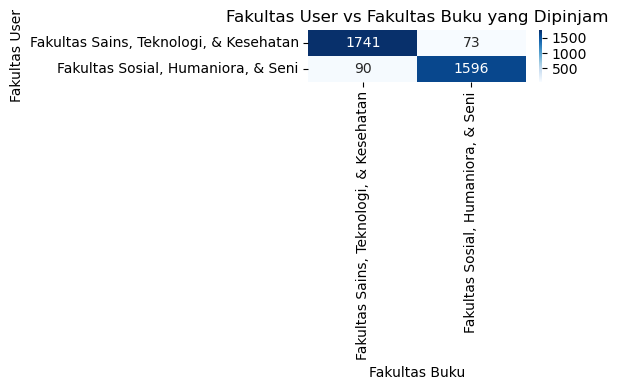

In [37]:
merged = df_trs.merge(df_user, on='id_user').merge(df_book[['id_buku','kategori','fakultas_terkait']], on='id_buku')
pivot = pd.crosstab(merged['fakultas_x'] if 'fakultas_x' in merged.columns else merged['fakultas'], merged['fakultas_terkait'])
plt.figure(figsize=(6,4))
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues')
plt.title('Fakultas User vs Fakultas Buku yang Dipinjam')
plt.ylabel('Fakultas User')
plt.xlabel('Fakultas Buku')
plt.tight_layout()
plt.show()

**Hasil Analisis Data Peminjaman** <br>

Hasil Analisis: <br>
1. Buku yang paling banyak terpinjam adalah dari FSHS (Dominasi Prodi Psikologi). Ini menunjukkan prodi FSHS terutama Psikologi lebih banyak membutuhkan referensi literatur (Peminjaman 9-11 kali/buku). Untuk FSTK sendiri banyak terpinjam di prodi Keperawatan dan Profesi Ners (Peminjaman 8-9 kali/buku)

2. Untuk pengembalian buku terlambat, rata-rata pembaca membutuhkan Waktu 18 hari Kembali dengan rata-rata jumlah halaman 331 halaman. Prodi FSTK (712) mendominasi keterlambatan pengembalian buku dibanidng FSHS (603). Prodi Informatika mendominasi keterlambatan hingga 195 buku sepanjang 2 tahun terakhir.

3. Dominasi peminjaman berdasarkan relevansi fakultas/prodi, ini memungkinkan sekali dalam pengembangan content base

4. Ada sekitar 160 an mahasiswa (FSTK + FSHS) yang meminjam buku lintas fakultas.

## 3. Build Model Content Based

### 3.1 Preprocessing Teks (Indo-Sastrawi)

In [38]:
# Import Dependencies
import re
import pandas as pd
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Inisisialisasi Sastrawi
_stemmer = StemmerFactory().create_stemmer()
_stopword_remover = StopWordRemoverFactory().create_stop_word_remover()

In [39]:
# Buat Fungsi untuk Bangun Content Soup (bahan masuk TF-IDF)
def build_content_soup(row: pd.Series) -> str:
    ''' 
    judul - kategori - sinopsis - pengarang - tags (gabungkan ke 1 teks utuh)
    '''

    judul = str(row.get("judul", ""))
    kategori = str(row.get("kategori", ""))
    sinopsis = str(row.get("sinopsis", ""))
    pengarang = str(row.get("pengarang", ""))
    tags = str(row.get("tags", ""))

    # Ulang kategori dan tags untuk menekankan bahwa variabel tersebut paling representatif
    soup = f"{judul} {kategori} {kategori} {kategori} {sinopsis} {pengarang} {tags} {tags}"

    return soup

In [40]:
# Jalankan fungsi content soup
df_book['content_soup'] = df_book.apply(build_content_soup, axis='columns')
df_book.head()

,id_buku,judul,pengarang,penerbit,tahun_terbit,fakultas_terkait,prodi_terkait,kategori,sinopsis,tags,bahasa,jenis_koleksi,jumlah_halaman,isbn,stok,content_soup
0,BK00001,Dasar Pemrograman Berorientasi Objek Edisi Ke-2,"Balidin Dongoran, S.T.",Gramedia Pustaka Utama,2024,"Fakultas Sains, Teknologi, & Kesehatan",Informatika,Pemrograman & Algoritma,Buku ini menyajikan kajian komprehensif mengen...,"struktur data, pemrograman, java, algoritma",Indonesia,E-book,452,978-0-218-19600-9,9999,Dasar Pemrograman Berorientasi Objek Edisi Ke-...
1,BK00002,Pengantar Web Development,Darimin Pradipta,Andi Publisher,2008,"Fakultas Sains, Teknologi, & Kesehatan",Informatika,Pemrograman & Algoritma,Buku ini menyajikan kajian komprehensif mengen...,"algoritma, coding, struktur data, java",Inggris,Fisik,303,978-0-86379-402-5,5,Pengantar Web Development Pemrograman & Algori...
2,BK00003,Dasar Web Development,"Lintang Siregar, S.T.",Erlangga,2007,"Fakultas Sains, Teknologi, & Kesehatan",Informatika,Pemrograman & Algoritma,Buku ini dirancang sebagai panduan untuk memah...,"coding, algoritma, pemrograman, python",Indonesia,Fisik,160,978-0-511-61559-7,3,Dasar Web Development Pemrograman & Algoritma ...
3,BK00004,Pemrograman Pemrograman Berorientasi Objek unt...,Yani Gunawan,Kencana Prenada,2022,"Fakultas Sains, Teknologi, & Kesehatan",Informatika,Pemrograman & Algoritma,Buku ini dirancang sebagai panduan untuk memah...,"python, kompleksitas, coding, struktur data",Indonesia,Fisik,314,978-0-618-49593-1,4,Pemrograman Pemrograman Berorientasi Objek unt...
4,BK00005,C++: Konsep dan Implementasi,"Betania Gunawan, S.H.",Elex Media Komputindo,2015,"Fakultas Sains, Teknologi, & Kesehatan",Informatika,Pemrograman & Algoritma,Buku ini menyajikan kajian komprehensif mengen...,"java, coding, algoritma, python",Inggris,Fisik,449,978-0-316-47525-9,7,C++: Konsep dan Implementasi Pemrograman & Alg...


In [41]:
# Buat Fungsi pembersihan teks di content soup

# 1. Fungsi Cleaning text
def clean_text(text: str) -> str:
    '''Lowecase all, delete non-alfabet, rapikan spasi, stopword, stemming'''
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    text = _stopword_remover.remove(text)
    text = _stemmer.stem(text)
    
    return text

In [42]:
# Aplikasikan ke content_soup
df_book['content_soup_clean'] = df_book['content_soup'].apply(clean_text)
df_book.head()

,id_buku,judul,pengarang,penerbit,tahun_terbit,fakultas_terkait,prodi_terkait,kategori,sinopsis,tags,bahasa,jenis_koleksi,jumlah_halaman,isbn,stok,content_soup,content_soup_clean
0,BK00001,Dasar Pemrograman Berorientasi Objek Edisi Ke-2,"Balidin Dongoran, S.T.",Gramedia Pustaka Utama,2024,"Fakultas Sains, Teknologi, & Kesehatan",Informatika,Pemrograman & Algoritma,Buku ini menyajikan kajian komprehensif mengen...,"struktur data, pemrograman, java, algoritma",Indonesia,E-book,452,978-0-218-19600-9,9999,Dasar Pemrograman Berorientasi Objek Edisi Ke-...,dasar pemrograman orientasi objek edisi pemrog...
1,BK00002,Pengantar Web Development,Darimin Pradipta,Andi Publisher,2008,"Fakultas Sains, Teknologi, & Kesehatan",Informatika,Pemrograman & Algoritma,Buku ini menyajikan kajian komprehensif mengen...,"algoritma, coding, struktur data, java",Inggris,Fisik,303,978-0-86379-402-5,5,Pengantar Web Development Pemrograman & Algori...,antar web development pemrograman algoritma pe...
2,BK00003,Dasar Web Development,"Lintang Siregar, S.T.",Erlangga,2007,"Fakultas Sains, Teknologi, & Kesehatan",Informatika,Pemrograman & Algoritma,Buku ini dirancang sebagai panduan untuk memah...,"coding, algoritma, pemrograman, python",Indonesia,Fisik,160,978-0-511-61559-7,3,Dasar Web Development Pemrograman & Algoritma ...,dasar web development pemrograman algoritma pe...
3,BK00004,Pemrograman Pemrograman Berorientasi Objek unt...,Yani Gunawan,Kencana Prenada,2022,"Fakultas Sains, Teknologi, & Kesehatan",Informatika,Pemrograman & Algoritma,Buku ini dirancang sebagai panduan untuk memah...,"python, kompleksitas, coding, struktur data",Indonesia,Fisik,314,978-0-618-49593-1,4,Pemrograman Pemrograman Berorientasi Objek unt...,pemrograman pemrograman orientasi objek mula p...
4,BK00005,C++: Konsep dan Implementasi,"Betania Gunawan, S.H.",Elex Media Komputindo,2015,"Fakultas Sains, Teknologi, & Kesehatan",Informatika,Pemrograman & Algoritma,Buku ini menyajikan kajian komprehensif mengen...,"java, coding, algoritma, python",Inggris,Fisik,449,978-0-316-47525-9,7,C++: Konsep dan Implementasi Pemrograman & Alg...,konsep implementasi pemrograman algoritma pemr...


In [43]:
# Save data hasil preprocessing
df_book.to_csv('data/data-buku-preprocessed.csv')
print('Buku berhasil disimpan')

Buku berhasil disimpan


In [44]:
# Hapus content_soup di data buku asli 
df_book.drop(columns=['content_soup', 'content_soup_clean'])

,id_buku,judul,pengarang,penerbit,tahun_terbit,fakultas_terkait,prodi_terkait,kategori,sinopsis,tags,bahasa,jenis_koleksi,jumlah_halaman,isbn,stok
0,BK00001,Dasar Pemrograman Berorientasi Objek Edisi Ke-2,"Balidin Dongoran, S.T.",Gramedia Pustaka Utama,2024,"Fakultas Sains, Teknologi, & Kesehatan",Informatika,Pemrograman & Algoritma,Buku ini menyajikan kajian komprehensif mengen...,"struktur data, pemrograman, java, algoritma",Indonesia,E-book,452,978-0-218-19600-9,9999
1,BK00002,Pengantar Web Development,Darimin Pradipta,Andi Publisher,2008,"Fakultas Sains, Teknologi, & Kesehatan",Informatika,Pemrograman & Algoritma,Buku ini menyajikan kajian komprehensif mengen...,"algoritma, coding, struktur data, java",Inggris,Fisik,303,978-0-86379-402-5,5
2,BK00003,Dasar Web Development,"Lintang Siregar, S.T.",Erlangga,2007,"Fakultas Sains, Teknologi, & Kesehatan",Informatika,Pemrograman & Algoritma,Buku ini dirancang sebagai panduan untuk memah...,"coding, algoritma, pemrograman, python",Indonesia,Fisik,160,978-0-511-61559-7,3
3,BK00004,Pemrograman Pemrograman Berorientasi Objek unt...,Yani Gunawan,Kencana Prenada,2022,"Fakultas Sains, Teknologi, & Kesehatan",Informatika,Pemrograman & Algoritma,Buku ini dirancang sebagai panduan untuk memah...,"python, kompleksitas, coding, struktur data",Indonesia,Fisik,314,978-0-618-49593-1,4
4,BK00005,C++: Konsep dan Implementasi,"Betania Gunawan, S.H.",Elex Media Komputindo,2015,"Fakultas Sains, Teknologi, & Kesehatan",Informatika,Pemrograman & Algoritma,Buku ini menyajikan kajian komprehensif mengen...,"java, coding, algoritma, python",Inggris,Fisik,449,978-0-316-47525-9,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1374,BK01375,Pengantar Content Creation,"Elisa Mandala, Puti Aryani",Erlangga,2022,"Fakultas Sosial, Humaniora, & Seni",Ilmu Komunikasi,Jurnalistik & Media Digital,Buku ini mengulas berbagai aspek penting dari ...,"konten kreator, produksi berita, komunikasi di...",Indonesia,Fisik,448,978-0-598-67874-4,8
1375,BK01376,Dasar-Dasar Komunikasi Digital Edisi Ke-3,Zelda Marbun,Nuha Medika,2012,"Fakultas Sosial, Humaniora, & Seni",Ilmu Komunikasi,Jurnalistik & Media Digital,Buku ini menyajikan kajian komprehensif mengen...,"komunikasi digital, jurnalistik, media digital...",Indonesia,Fisik,540,978-1-58548-596-3,6
1376,BK01377,Media Sosial di Era Digital,Wulan Simanjuntak,Informatika Bandung,2018,"Fakultas Sosial, Humaniora, & Seni",Ilmu Komunikasi,Jurnalistik & Media Digital,Buku ini dirancang sebagai panduan untuk memah...,"media sosial, produksi berita, komunikasi digi...",Indonesia,E-book,272,978-0-8249-1165-2,9999
1377,BK01378,Pengantar Content Creation,Cahya Ardianto,Kencana Prenada,2012,"Fakultas Sosial, Humaniora, & Seni",Ilmu Komunikasi,Jurnalistik & Media Digital,Buku ini memberikan pemahaman menyeluruh tenta...,"jurnalistik, media sosial, konten kreator, pro...",Inggris,Fisik,310,978-0-245-39313-6,7


In [45]:
df_buku_prep = pd.read_csv('data/data-buku-preprocessed.csv')
df_buku_prep[['judul', 'content_soup_clean']].head(5)

,judul,content_soup_clean
0,Dasar Pemrograman Berorientasi Objek Edisi Ke-2,dasar pemrograman orientasi objek edisi pemrog...
1,Pengantar Web Development,antar web development pemrograman algoritma pe...
2,Dasar Web Development,dasar web development pemrograman algoritma pe...
3,Pemrograman Pemrograman Berorientasi Objek unt...,pemrograman pemrograman orientasi objek mula p...
4,C++: Konsep dan Implementasi,konsep implementasi pemrograman algoritma pemr...


In [46]:
df_buku_prep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1379 entries, 0 to 1378
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          1379 non-null   int64 
 1   id_buku             1379 non-null   object
 2   judul               1379 non-null   object
 3   pengarang           1379 non-null   object
 4   penerbit            1379 non-null   object
 5   tahun_terbit        1379 non-null   int64 
 6   fakultas_terkait    1379 non-null   object
 7   prodi_terkait       1379 non-null   object
 8   kategori            1379 non-null   object
 9   sinopsis            1379 non-null   object
 10  tags                1379 non-null   object
 11  bahasa              1379 non-null   object
 12  jenis_koleksi       1379 non-null   object
 13  jumlah_halaman      1379 non-null   int64 
 14  isbn                1379 non-null   object
 15  stok                1379 non-null   int64 
 16  content_soup        1379

In [47]:
df_buku_prep = df_buku_prep.drop(columns=['Unnamed: 0'])

In [48]:
df_buku_prep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1379 entries, 0 to 1378
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id_buku             1379 non-null   object
 1   judul               1379 non-null   object
 2   pengarang           1379 non-null   object
 3   penerbit            1379 non-null   object
 4   tahun_terbit        1379 non-null   int64 
 5   fakultas_terkait    1379 non-null   object
 6   prodi_terkait       1379 non-null   object
 7   kategori            1379 non-null   object
 8   sinopsis            1379 non-null   object
 9   tags                1379 non-null   object
 10  bahasa              1379 non-null   object
 11  jenis_koleksi       1379 non-null   object
 12  jumlah_halaman      1379 non-null   int64 
 13  isbn                1379 non-null   object
 14  stok                1379 non-null   int64 
 15  content_soup        1379 non-null   object
 16  content_soup_clean  1379

### 3.2 Feature Extraction TF-IDF

In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
tfidf_matrix = tfidf.fit_transform(df_buku_prep['content_soup_clean'])

print('Ukuran TF-IDF Matrix: ', tfidf_matrix.shape)
print('Contoh fitur (term): ', tfidf.get_feature_names_out()[:30])

Ukuran TF-IDF Matrix:  (1379, 5000)
Contoh fitur (term):  ['abnormal' 'abnormal psikologi' 'abnormal teori' 'abyasa' 'ade'
 'ade laksmiwati' 'ade oktaviani' 'ade putra' 'adhiarja'
 'adhiarja samosir' 'adhiarja widodo' 'adika' 'adika habibi' 'adikara'
 'adikara januar' 'adikara yuniar' 'adinata' 'adinata ramadan'
 'adinata suwarno' 'aditya' 'aditya marpaung' 'administrasi'
 'administrasi bisnis' 'administrasi manajemen' 'administrasi operasional'
 'adriansyah' 'adriansyah awat' 'adriansyah media' 'adriansyah mitra'
 'adriansyah public']


In [50]:
# Contoh:
feature_names = tfidf.get_feature_names_out()
tfidf_scores = tfidf_matrix[0].toarray().flatten()
top_idx = tfidf_scores.argsort()[-10:][::-1]

print(f"Judul: {df_buku_prep.iloc[0]['judul']}\n")
print('Top 10 term dengan bobot TF-IDF tertinggi:')
for i in top_idx:
    if tfidf_scores[i] > 0:
        print(f'  {feature_names[i]:20s} : {tfidf_scores[i]:.4f}')

Judul: Dasar Pemrograman Berorientasi Objek Edisi Ke-2

Top 10 term dengan bobot TF-IDF tertinggi:
  pemrograman          : 0.4893
  algoritma            : 0.4194
  struktur data        : 0.2268
  struktur             : 0.2268
  java algoritma       : 0.2244
  pemrograman algoritma : 0.2097
  data pemrograman     : 0.2066
  pemrograman java     : 0.2003
  algoritma struktur   : 0.1620
  java                 : 0.1558


### 4.1 Build Model Content Based Cosine Similarity

In [51]:
from cbf_recomender import BookRecommender

recommender = BookRecommender(df_buku_prep).fit()
print('Similarity matrix shape: ', recommender.sim_matrix.shape)

Similarity matrix shape:  (1379, 1379)


ada 1379 item dengan similarity

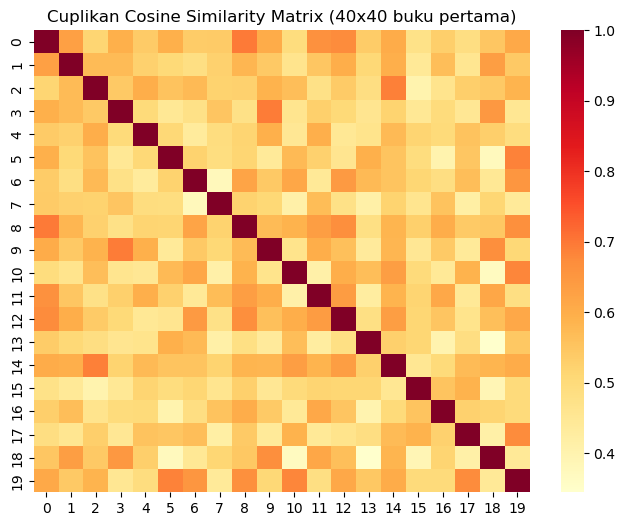

In [52]:
plt.figure(figsize=(8,6))
sample_sim = recommender.sim_matrix[:20, :20]
sns.heatmap(sample_sim, cmap='YlOrRd')
plt.title('Cuplikan Cosine Similarity Matrix (40x40 buku pertama)')
plt.show()

### 4.2 Contoh Rekomendasi

#### 4.2.a Rekomendasi Item_to_item

In [53]:
contoh_buku = df_buku_prep.iloc[100]
contoh_buku[['id_buku', 'judul', 'content_soup_clean']]

id_buku                                                         BK00101
judul                    Membangun Sistem Machine Learning Edisi Revisi
content_soup_clean    bangun sistem machine learning edisi revisi ce...
Name: 100, dtype: object

In [54]:
print('Buku acuan  :', contoh_buku['judul'])
print('Kategori []   :', contoh_buku['kategori'])
print()
recommender.recommend_by_item(contoh_buku['id_buku'], top_n=10)

Buku acuan  : Membangun Sistem Machine Learning Edisi Revisi
Kategori []   : Kecerdasan Buatan & Data Science



,id_buku,judul,pengarang,kategori,fakultas_terkait,prodi_terkait,similarity_score
0,BK00073,Konsep Dasar Kecerdasan Buatan,Jelita Sitorus,Kecerdasan Buatan & Data Science,"Fakultas Sains, Teknologi, & Kesehatan",Informatika,0.754311
1,BK00126,Konsep Dasar Data Science,Bella Kusumo,Kecerdasan Buatan & Data Science,"Fakultas Sains, Teknologi, & Kesehatan",Informatika,0.750978
2,BK00123,Data Science untuk Pemula Edisi Ke-3,Tgk. Daryani Winarno,Kecerdasan Buatan & Data Science,"Fakultas Sains, Teknologi, & Kesehatan",Informatika,0.731113
3,BK00070,Pengantar Machine Learning Edisi Revisi,Lasmono Sudiati,Kecerdasan Buatan & Data Science,"Fakultas Sains, Teknologi, & Kesehatan",Informatika,0.724599
4,BK00110,Membangun Sistem Natural Language Processing,"Tgk. Gara Yuliarti, S.E.I",Kecerdasan Buatan & Data Science,"Fakultas Sains, Teknologi, & Kesehatan",Informatika,0.702777
5,BK00124,Membangun Sistem Kecerdasan Buatan,Yance Halimah,Kecerdasan Buatan & Data Science,"Fakultas Sains, Teknologi, & Kesehatan",Informatika,0.693706
6,BK00106,Konsep Dasar Natural Language Processing Edisi...,Jamal Astuti,Kecerdasan Buatan & Data Science,"Fakultas Sains, Teknologi, & Kesehatan",Informatika,0.686223
7,BK00096,Membangun Sistem Kecerdasan Buatan,Drs. Ida Hasanah,Kecerdasan Buatan & Data Science,"Fakultas Sains, Teknologi, & Kesehatan",Informatika,0.685945
8,BK00094,Pengantar Kecerdasan Buatan,Sutan Warsita Susanti,Kecerdasan Buatan & Data Science,"Fakultas Sains, Teknologi, & Kesehatan",Informatika,0.682000
9,BK00114,Membangun Sistem Data Mining,Ciaobella Siregar,Kecerdasan Buatan & Data Science,"Fakultas Sains, Teknologi, & Kesehatan",Informatika,0.678746


#### 4.2.b Rekomendasi User_to_Item

In [55]:
# Ambil User
user_aktif = 'USR00267'

# Ambil Riwayat Buku yang pernah dipinjam
riwayat = df_trs[df_trs['id_user'] == user_aktif]['id_buku'].tolist()
riwayat

['BK00570',
 'BK00625',
 'BK00587',
 'BK00613',
 'BK00591',
 'BK00591',
 'BK00996',
 'BK00630',
 'BK00586',
 'BK00692',
 'BK00631',
 'BK00765',
 'BK00478',
 'BK00586',
 'BK00567',
 'BK00656',
 'BK00515']

In [56]:
info_user = df_user[df_user['id_user'] == user_aktif].iloc[0]
print('User        :', info_user['nama'])
print('Prodi       :', info_user['prodi'])
print('Jml riwayat :', len(riwayat))
print()

recommender.recommend_by_user_profile(riwayat, top_n=10)

User        : Lanjar Thamrin
Prodi       : Farmasi
Jml riwayat : 17



,id_buku,judul,pengarang,kategori,fakultas_terkait,prodi_terkait,similarity_score
0,BK00611,Kimia Farmasi Klinis Edisi Terbaru,Vivi Ardianto,Farmakologi & Kefarmasian,"Fakultas Sains, Teknologi, & Kesehatan",Farmasi,0.460527
1,BK00603,Kimia Farmasi untuk Praktik Klinis,"Almira Nuraini, S.Ked",Farmakologi & Kefarmasian,"Fakultas Sains, Teknologi, & Kesehatan",Farmasi,0.447580
2,BK00563,Dasar Farmasi Klinis,Yuni Suwarno,Farmakologi & Kefarmasian,"Fakultas Sains, Teknologi, & Kesehatan",Farmasi,0.447067
3,BK00583,Kimia Farmasi Klinis,Jessica Hastuti,Farmakologi & Kefarmasian,"Fakultas Sains, Teknologi, & Kesehatan",Farmasi,0.442530
4,BK00609,Dasar Toksikologi,Wirda Haryanti,Farmakologi & Kefarmasian,"Fakultas Sains, Teknologi, & Kesehatan",Farmasi,0.435055
5,BK00610,Dasar Farmakologi,"Banara Putra, S.I.Kom, Ozy Siregar",Farmakologi & Kefarmasian,"Fakultas Sains, Teknologi, & Kesehatan",Farmasi,0.434995
6,BK00560,Farmasi Klinis untuk Praktik Klinis,"Ridwan Sihombing, M.TI.",Farmakologi & Kefarmasian,"Fakultas Sains, Teknologi, & Kesehatan",Farmasi,0.430262
7,BK00601,Farmasi Klinis Klinis,Ayu Hartati,Farmakologi & Kefarmasian,"Fakultas Sains, Teknologi, & Kesehatan",Farmasi,0.429717
8,BK00624,Farmasetika Klinis,Hairyanto Pertiwi,Farmakologi & Kefarmasian,"Fakultas Sains, Teknologi, & Kesehatan",Farmasi,0.428458
9,BK00566,Kimia Farmasi untuk Praktik Klinis,"Maryadi Iswahyudi, S.Sos",Farmakologi & Kefarmasian,"Fakultas Sains, Teknologi, & Kesehatan",Farmasi,0.427704


### 6. Evaluasi

In [57]:
import importlib
import cbf_recomender
importlib.reload(cbf_recomender)
from cbf_recomender import evaluate_precision_at_k, evaluate_category_relevance_at_k

In [68]:
jml_user = df_trs.id_user.nunique()
print(f"Jumlah user yang melakukan transasksi (unique): {jml_user}")

Jumlah user yang melakukan transasksi (unique): 380


In [ ]:
RANDOM_STATE = 42
min_riwayat_pinjam = 3
sample_user_trs = 250

hasil_exact = evaluate_precision_at_k(recommender, df_trs, k=10, sample_user=sample_user_trs, min_riwayat=min_riwayat_pinjam, random_state=RANDOM_STATE)
hasil_kategori = evaluate_category_relevance_at_k(recommender, df_trs, k=10, sample_user=sample_user_trs, min_riwayat=min_riwayat_pinjam, random_state=RANDOM_STATE)

print('=== Precision@10 (HIT buku) ===')
print(hasil_exact)
print()
print('=== Relevansi Kategori @10 ===')
print(hasil_kategori)

=== Precision@10 (HIT buku) ===
{'precision_at_k': 0.112, 'hits': 28, 'total_evaluated': 250, 'k': 10}

=== Relevansi Kategori @10 ===
{'avg_precision_at_k_kategori': 0.6132, 'category_hit_rate': 0.62, 'total_evaluated': 250, 'k': 10}


### 7. Evaluate Scenario

SKENARIO 1: <br>
min_riwayat_pinjam = 3
sample_user_trs = 100

SKENARIO 2: <br>
min_riwayat_pinjam = 2
sample_user_trs = 100

SKENARIO 3: <br>
min_riwayat_pinjam = 3
sample_user_trs = 150

SKENARIO 4: <br>
min_riwayat_pinjam = 2
sample_user_trs = 150

SKENARIO 5: <br>
min_riwayat_pinjam = 3
sample_user_trs = 300

SKENARIO 6: <br>
min_riwayat_pinjam = 4
sample_user_trs = 300

In [91]:
# SKENARIO 1
skenario_1_test = evaluate_category_relevance_at_k(recommender, df_trs, k=10, sample_user=100, min_riwayat=3, random_state=RANDOM_STATE)
skenario_1_test

{'avg_precision_at_k_kategori': 0.632,
 'category_hit_rate': 0.64,
 'total_evaluated': 100,
 'k': 10}

In [88]:
# SKENARIO 2
skenario_2_test = evaluate_category_relevance_at_k(recommender, df_trs, k=10, sample_user=100, min_riwayat=2, random_state=RANDOM_STATE)
skenario_2_test

{'avg_precision_at_k_kategori': 0.578,
 'category_hit_rate': 0.59,
 'total_evaluated': 100,
 'k': 10}

In [89]:
# SKENARIO 3
skenario_3_test = evaluate_category_relevance_at_k(recommender, df_trs, k=10, sample_user=150, min_riwayat=3, random_state=RANDOM_STATE)
skenario_3_test

{'avg_precision_at_k_kategori': 0.634,
 'category_hit_rate': 0.64,
 'total_evaluated': 150,
 'k': 10}

In [92]:
# SKENARIO 4
skenario_4_test = evaluate_category_relevance_at_k(recommender, df_trs, k=10, sample_user=150, min_riwayat=2, random_state=RANDOM_STATE)
skenario_4_test

{'avg_precision_at_k_kategori': 0.578,
 'category_hit_rate': 0.5866666666666667,
 'total_evaluated': 150,
 'k': 10}

In [93]:
# SKENARIO 5
skenario_5_test = evaluate_category_relevance_at_k(recommender, df_trs, k=10, sample_user=300, min_riwayat=3, random_state=RANDOM_STATE)
skenario_5_test

{'avg_precision_at_k_kategori': 0.6013333333333334,
 'category_hit_rate': 0.61,
 'total_evaluated': 300,
 'k': 10}

In [94]:
# SKENARIO 6
skenario_6_test = evaluate_category_relevance_at_k(recommender, df_trs, k=10, sample_user=300, min_riwayat=4, random_state=RANDOM_STATE)
skenario_6_test

{'avg_precision_at_k_kategori': 0.6146666666666666,
 'category_hit_rate': 0.6233333333333333,
 'total_evaluated': 300,
 'k': 10}